In [3]:
from google.colab import drive
drive.mount('/content/drive')

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re # Import regular expressions for text processing


In [5]:
# Load the CSV file
df = pd.read_csv('/content/drive/MyDrive/Sentiment_Analysis/imdb_combined.csv')

# Display the first five rows
df.head()

,review,sentiment
0,"This film is fun, if your a person who likes a...",pos
1,My fondness for Chris Rock varies with his mov...,pos
2,High school friends Andre Kriegman and Cal Gab...,pos
3,The story is about a little girl growing up in...,pos
4,"Then you must see this film, to understand the...",pos


In [6]:
# Display the number of rows and columns
print("Dataset Shape:")
print(f"Number of reviews: {df.shape[0]:,}")
print(f"Number of attributes: {df.shape[1]}")

# Display the column names
print("\nDataset Attributes:")
print(df.columns.tolist())

Dataset Shape:
Number of reviews: 50,010
Number of attributes: 2

Dataset Attributes:
['review', 'sentiment']


In [7]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50010 entries, 0 to 50009
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50010 non-null  object
 1   sentiment  50010 non-null  object
dtypes: object(2)
memory usage: 781.5+ KB


In [8]:
# Count missing values in each column
missing_values = df.isnull().sum()

# Calculate the percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a summary table
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

# Display the missing-value summary
missing_summary

,Missing Values,Missing Percentage
review,0,0.0
sentiment,0,0.0


In [9]:
# Count reviews that contain only whitespace or are empty
empty_reviews = df["review"].fillna("").str.strip().eq("").sum()

print(f"Number of empty reviews: {empty_reviews}")

Number of empty reviews: 0


In [10]:
# Count completely duplicated rows
duplicate_count = df.duplicated().sum()

# Calculate the percentage of duplicated records
duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Number of duplicate records: {duplicate_count}")
print(f"Percentage of duplicate records: {duplicate_percentage:.2f}%")

Number of duplicate records: 428
Percentage of duplicate records: 0.86%


In [11]:
# Display the unique sentiment classes
print("Sentiment Classes:")
print(df["sentiment"].unique())

# Count the number of reviews in each sentiment class
sentiment_counts = df["sentiment"].value_counts()

print("\nSentiment Distribution:")
print(sentiment_counts)

Sentiment Classes:
['pos' 'neg']

Sentiment Distribution:
sentiment
pos    25010
neg    25000
Name: count, dtype: int64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all plots
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# Set default figure size
plt.rcParams["figure.figsize"] = (10, 6)

# Improve title appearance
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.titleweight"] = "bold"

# Improve axis labels
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.labelweight"] = "bold"

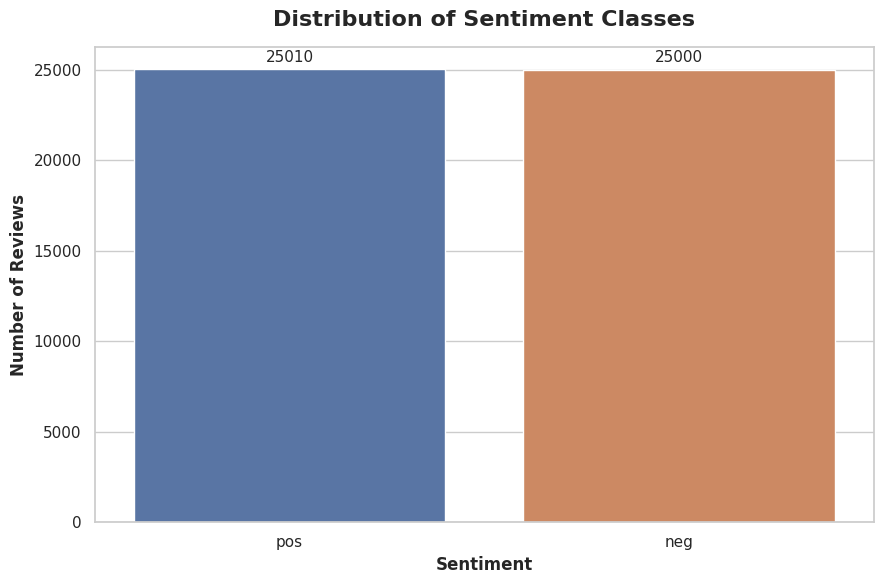

In [13]:
plt.figure(figsize=(9, 6))

ax = sns.countplot(
    data=df,
    x='sentiment',
    hue='sentiment',
    legend=False
)

plt.title('Distribution of Sentiment Classes', pad=15)
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=11)

plt.tight_layout()
plt.show()

In [14]:
# Calculate the number of characters in each review
df['review_length'] = df['review'].str.len()

# Descriptive statistics for review character length
df['review_length'].describe()

,review_length
count,50010.000000
mean,1309.384763
std,989.698530
min,32.000000
25%,699.000000
50%,970.000000
75%,1590.000000
max,13704.000000


In [15]:
# Calculate the number of words in each review
df["word_count"] = df["review"].str.split().str.len()

# Display descriptive statistics
df["word_count"].describe()

,word_count
count,50010.000000
mean,231.150210
std,171.339385
min,4.000000
25%,126.000000
50%,173.000000
75%,280.000000
max,2470.000000


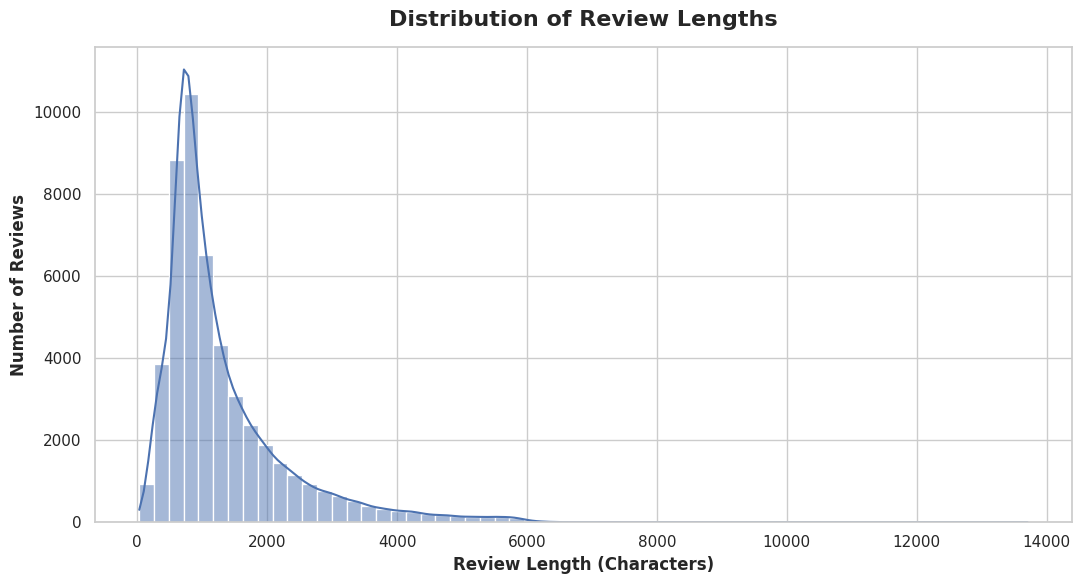

In [16]:
plt.figure(figsize=(11, 6))

sns.histplot(
    data=df,
    x='review_length',
    bins=60,
    kde=True
)

plt.title('Distribution of Review Lengths', pad=15)
plt.xlabel('Review Length (Characters)')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

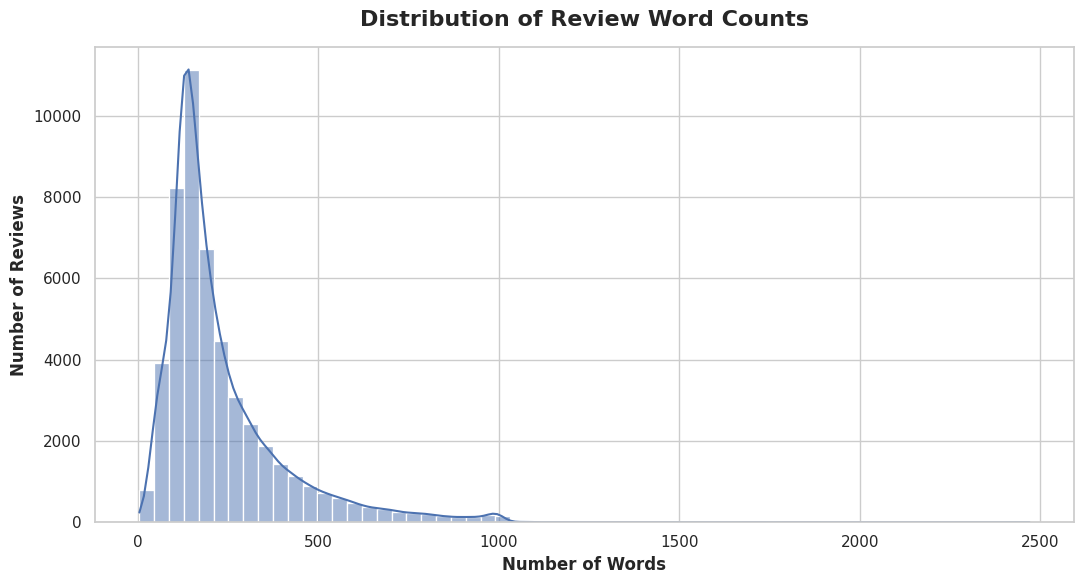

In [17]:
plt.figure(figsize=(11, 6))

sns.histplot(
    data=df,
    x='word_count',
    bins=60,
    kde=True
)

plt.title('Distribution of Review Word Counts', pad=15)
plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

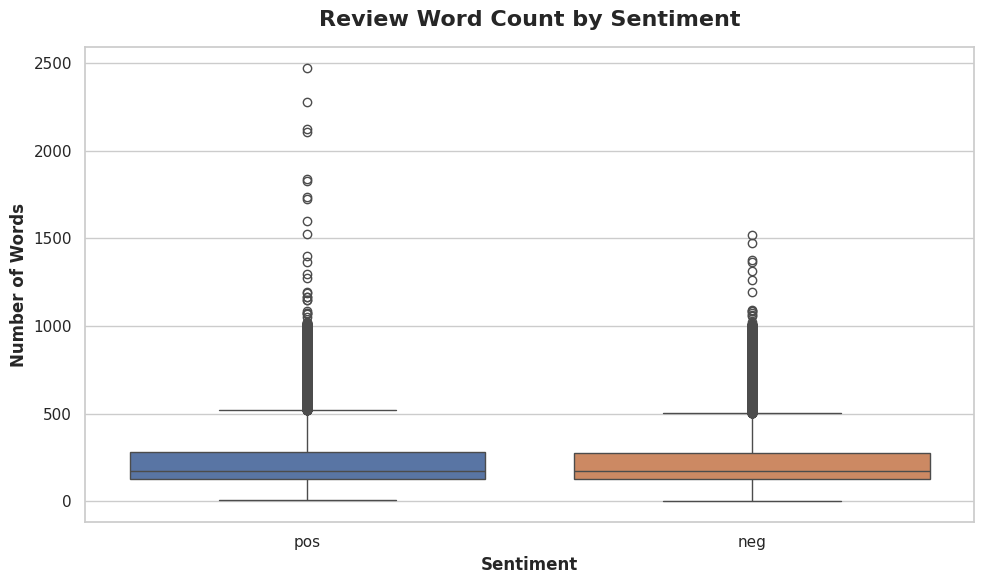

In [18]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='sentiment',
    y='word_count',
    hue='sentiment',
    legend=False
)

plt.title('Review Word Count by Sentiment', pad=15)
plt.xlabel('Sentiment')
plt.ylabel('Number of Words')

plt.tight_layout()
plt.show()

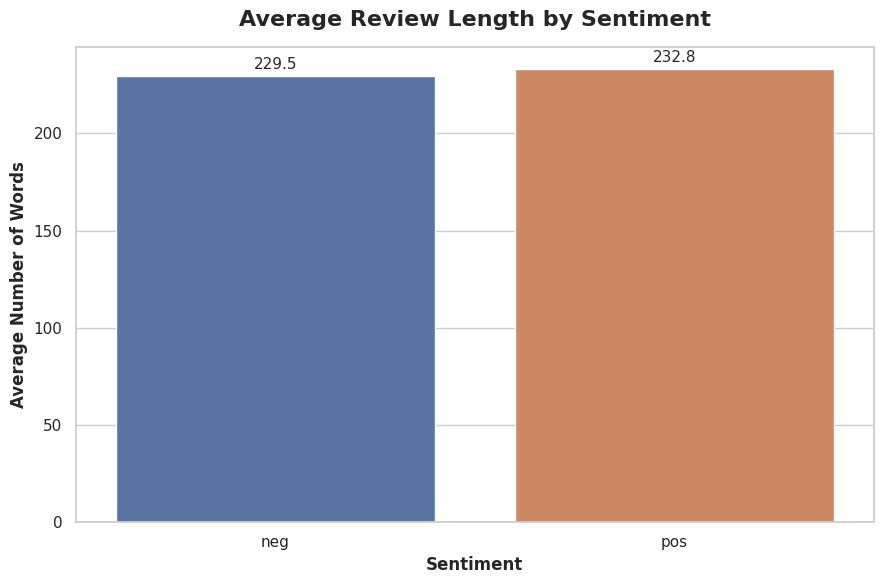

In [19]:
mean_word_count = (
    df.groupby('sentiment')['word_count']
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=mean_word_count,
    x='sentiment',
    y='word_count',
    hue='sentiment',
    legend=False
)

plt.title('Average Review Length by Sentiment', pad=15)
plt.xlabel('Sentiment')
plt.ylabel('Average Number of Words')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=3,
        fontsize=11
    )

plt.tight_layout()
plt.show()

In [22]:
# Import the English stopword list from NLTK
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Download the stopword list
nltk.download("stopwords")

# Load English stopwords
stop_words = set(stopwords.words("english"))

# Function to clean text for frequency analysis
def get_words(text):
    """
    Convert text to lowercase, remove non-alphabetic characters,
    and remove common English stopwords.
    """

    # Convert text to lowercase
    text = text.lower()

    # Keep only alphabetic words
    words = re.findall(r"\b[a-z]+\b", text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    return words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
# Extract words from all reviews
all_words = []

for review in df["review"]:
    all_words.extend(get_words(review))

# Count how frequently each word occurs
word_counts = Counter(all_words)

# Display the 20 most common words
most_common_words = word_counts.most_common(20)

# Convert to DataFrame
top_words_df = pd.DataFrame(
    most_common_words,
    columns=['word', 'frequency']
)

# Display results
print("Top 20 most frequent words:")
display(top_words_df)

Top 20 most frequent words:


,word,frequency
0,br,201979
1,movie,87986
2,film,79722
3,one,53611
4,like,40175
5,good,29757
6,time,25118
7,even,24871
8,would,24606
9,story,23122


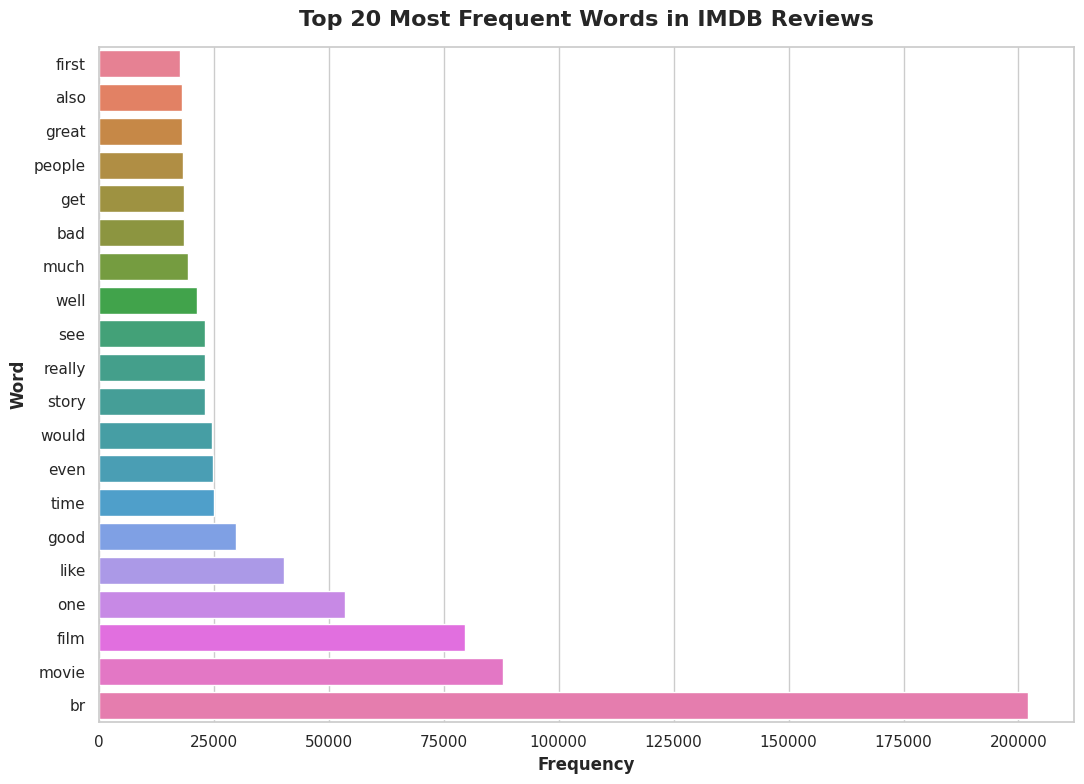

In [24]:
# Get the 20 most frequent words
top_words = word_counts.most_common(20)

# Convert to DataFrame
top_words_df = pd.DataFrame(
    top_words,
    columns=['word', 'frequency']
)

# Reverse order for horizontal bar chart
top_words_df = top_words_df.sort_values('frequency')

plt.figure(figsize=(11, 8))

sns.barplot(
    data=top_words_df,
    x='frequency',
    y='word',
    hue='word',
    legend=False
)

plt.title('Top 20 Most Frequent Words in IMDB Reviews', pad=15)
plt.xlabel('Frequency')
plt.ylabel('Word')

plt.tight_layout()
plt.show()

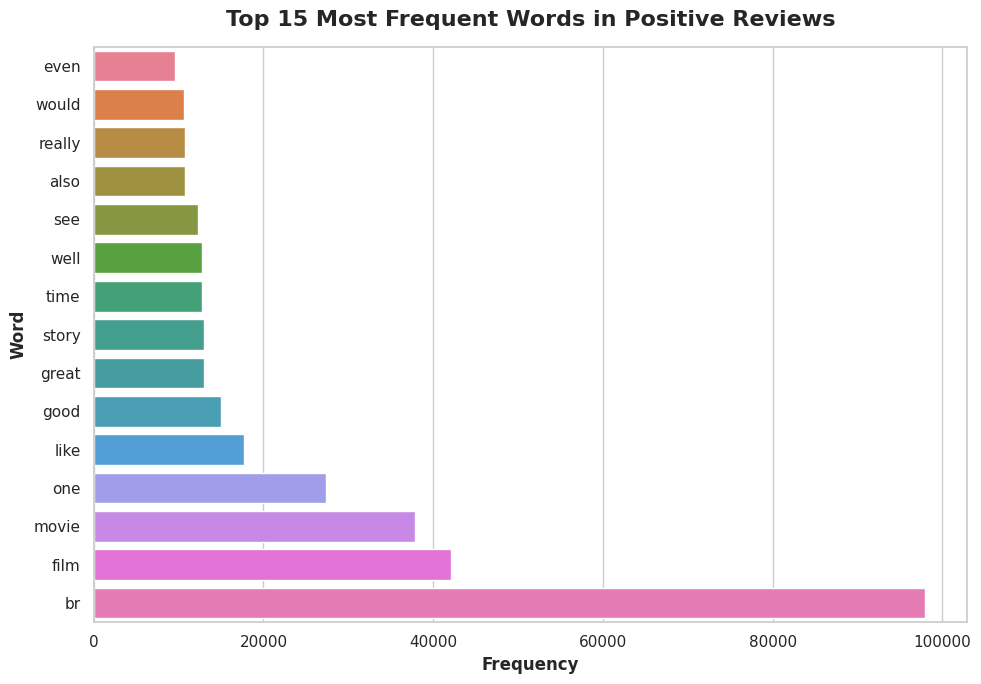

In [27]:
# Get only positive reviews
positive_reviews = df[df['sentiment'] == 'pos']['review'].astype(str)

# Combine all positive reviews
positive_text = ' '.join(positive_reviews).lower()

# Extract words
positive_words = re.findall(r'\b[a-z]+\b', positive_text)

# Remove stop words
positive_filtered_words = [
    word for word in positive_words
    if word not in stop_words
]

# Count positive words
positive_counts = Counter(positive_filtered_words)

# Get top 15
positive_top = positive_counts.most_common(15)

# Convert to DataFrame
positive_df = pd.DataFrame(
    positive_top,
    columns=['word', 'frequency']
)

positive_plot = positive_df.sort_values('frequency')

plt.figure(figsize=(10, 7))

sns.barplot(
    data=positive_plot,
    x='frequency',
    y='word',
    hue='word',
    legend=False
)

plt.title(
    'Top 15 Most Frequent Words in Positive Reviews',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Frequency')
plt.ylabel('Word')

plt.tight_layout()
plt.show()

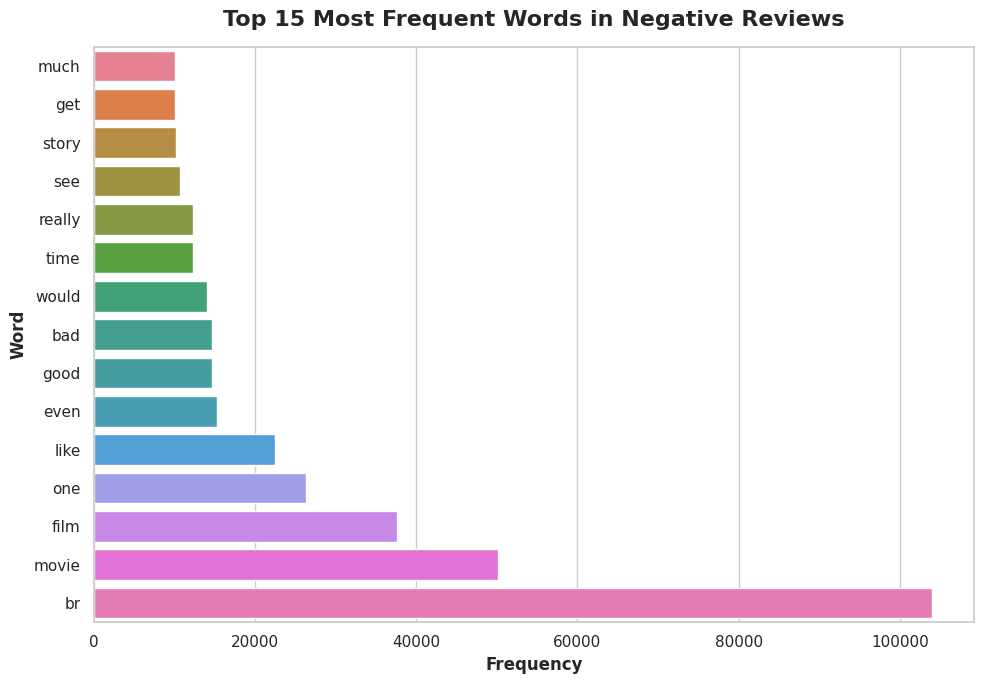

In [28]:
negative_reviews = df[df['sentiment'] == 'neg']['review'].astype(str)

negative_text = ' '.join(negative_reviews).lower()

negative_words = re.findall(r'\b[a-z]+\b', negative_text)

negative_filtered_words = [
    word for word in negative_words
    if word not in stop_words
]

negative_counts = Counter(negative_filtered_words)

negative_top = negative_counts.most_common(15)

negative_df = pd.DataFrame(
    negative_top,
    columns=['word', 'frequency']
)

negative_plot = negative_df.sort_values('frequency')

plt.figure(figsize=(10, 7))

sns.barplot(
    data=negative_plot,
    x='frequency',
    y='word',
    hue='word',
    legend=False
)

plt.title(
    'Top 15 Most Frequent Words in Negative Reviews',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Frequency')
plt.ylabel('Word')

plt.tight_layout()
plt.show()

In [29]:
# Count reviews containing HTML tags
html_pattern = r"<[^>]+>"

html_count = df["review"].str.contains(
    html_pattern,
    regex=True,
    na=False
).sum()

html_percentage = (html_count / len(df)) * 100

print(f"Reviews containing HTML tags: {html_count:,}")
print(f"Percentage containing HTML tags: {html_percentage:.2f}%")

Reviews containing HTML tags: 29,206
Percentage containing HTML tags: 58.40%


In [30]:
# Count reviews containing repeated exclamation marks
exclamation_count = df["review"].str.contains(
    r"!{2,}",
    regex=True,
    na=False
).sum()

# Count reviews containing repeated question marks
question_count = df["review"].str.contains(
    r"\?{2,}",
    regex=True,
    na=False
).sum()

print(f"Reviews containing repeated exclamation marks: {exclamation_count:,}")
print(f"Reviews containing repeated question marks: {question_count:,}")

Reviews containing repeated exclamation marks: 3,301
Reviews containing repeated question marks: 1,068
